# __🐜__ __Ant Colony Foraging Simulation__

#### This notebook allows you to run the program process step by step.

> **⚠️ Note:** Clear all outputs before re-running to avoid state carryover. Occasionally restart the kernel if needed.

<br>

---
---

## Generate Random Food Sources

Create 10 food sources with random positions and characteristics (quality, quantity, accessibility). Save original values for comparison later.

In [16]:
import math
import random as rd
from sklearn.preprocessing import MinMaxScaler
from copy import deepcopy


NEST = (0, 0)
SIZE = 40
# distance ants can perceive food sources (in degrees)
ANT_PERCEPTION = 3  # degrees

# center of each food patch (assumed to be spheres for simplicity)
food_locations = [(rd.randint(-SIZE, SIZE), rd.randint(-SIZE, SIZE)) for _ in range(10)]

food_locations_angles = [round(math.degrees(math.atan2(y - NEST[1], x - NEST[0])) % 360, 2) for x, y in food_locations]

# distance from nest to center of each food patch
food_distances = [math.sqrt((x - NEST[0]) ** 2 + (y - NEST[1]) ** 2) for x, y in food_locations]
# nutritional value for ants (assessed by chemoreceptors for sugar, protein, and freshness)
food_quality = [rd.randint(1, 10) for _ in range(10)]
food_quantity = [rd.randint(100, 1000) for _ in range(10)]  # Increased for better visualization
food_patch_size = [math.sqrt(x) / 10 for x in food_quantity]  # larger patches tend to have more food
# obstacles, terrain, or predators affecting ease of access
food_ease_of_access = [rd.randint(1, 10) for _ in range(10)]

# 💾 SAVE ORIGINAL VALUES before modification from simulation so they can be used by the random simulation
#    and for the final comparison of the two simulations
original_food_quantity = deepcopy(food_quantity)

food_quantity_copy = deepcopy(food_quantity)




## Calculate Food Source Rankings

Normalize each food characteristic (distance, quality, quantity, ease of access) and combine them into a single score. Display all food sources with their attributes.

In [17]:
def normalize(data_list, feature_bottom, feature_top, invert=False):
    temp_list = data_list.copy()
    temp_list.append(feature_bottom)
    temp_list.append(feature_top)
    scaler = MinMaxScaler(feature_range=(.1, 1.1))
    normalized = scaler.fit_transform([[x] for x in temp_list])

    # for features where LOWER is BETTER, invert the values
    if invert:
        with_edges = [1.2 - x[0] for x in normalized]
        return with_edges[:-2]  # remove added edges
    else:
        with_edges = [x[0] for x in normalized]
        return with_edges[:-2]  # remove added edges


# Constants for the min and max values for normalization. We will be using static values to mimic ant knowledge.
# As it is not possible for ants to have global knowledge of all food sources, they rely on known min/max values.
# These values can be obviously be adjusted.
min_dist = 1
max_dist = math.sqrt((SIZE - NEST[0]) ** 2 + (SIZE - NEST[1]) ** 2)
min_qual = 1
max_qual = 10
min_quant = 100
max_quant = 1000
min_ease = 1
max_ease = 10    
    
norm_dist = normalize(food_distances, min_dist, max_dist, invert=True)
norm_qual = normalize(food_quality, min_qual, max_qual, invert=False)
norm_quant = normalize(food_quantity, min_quant, max_quant, invert=False)
norm_ease = normalize(food_ease_of_access, min_ease, max_ease, invert=False)


# Combine all into a single score (you can adjust the weights as needed)
food_scores = [
    # patch size is not included in score calculation as it is not a factor to consider when evaluating the food source
    # as ants prioritize distance, quality, quantity, and ease of access and patch size is correlated with quantity
    nd * 0.4 + nqlty * 0.225 + nqty * 0.225 + nea * 0.15
    for nd, nqlty, nqty, nea in zip(norm_dist, norm_qual, norm_quant, norm_ease)
]

    
    
# Display the food sources
print("🐜 FOOD SOURCES INITIALIZED:\n")
print(f"{'ID':<4} {'Location':<15} {'Dist':<7} {'Angle':<7} {'Quality':<9} {'Quantity':<10} {'Ease':<6} {'Patch-Size':<10} {'Score':<6}")
print("=" * 85)
for i in range(len(food_locations)):
    print(f"F{i+1:<3} {str(food_locations[i]):<15} {food_distances[i]:<7.2f} "
          f"{food_locations_angles[i]:<7.2f} {food_quality[i]:<9.0f} "
          f"{food_quantity[i]:<10} {food_ease_of_access[i]:<6.0f} {food_patch_size[i]:<10.1f} {food_scores[i]:<6.2f} ")

print("\n✅ Environment ready for ant colony simulation!") 

🐜 FOOD SOURCES INITIALIZED:

ID   Location        Dist    Angle   Quality   Quantity   Ease   Patch-Size Score 
F1   (-4, -39)       39.20   264.14  5         811        5      2.8        0.57   
F2   (-9, -27)       28.46   251.57  2         271        6      1.6        0.45   
F3   (-39, -8)       39.81   191.59  4         552        5      2.3        0.48   
F4   (-17, -27)      31.91   237.80  10        692        10     2.6        0.80   
F5   (-21, -26)      33.42   231.07  2         592        6      2.4        0.50   
F6   (18, 30)        34.99   59.04   6         891        9      3.0        0.71   
F7   (-22, 25)       33.30   131.35  10        380        10     1.9        0.71   
F8   (-21, 33)       39.12   122.47  5         892        6      3.0        0.61   
F9   (11, 35)        36.69   72.55   9         605        4      2.5        0.62   
F10  (-34, 18)       38.47   152.10  7         900        1      3.0        0.58   

✅ Environment ready for ant colony simulation!


## Visualize Environment Layout

Plot the nest, food sources, and their detection zones. Food sources are colored by score (darker green = better), with dashed circles showing the angular coverage area.

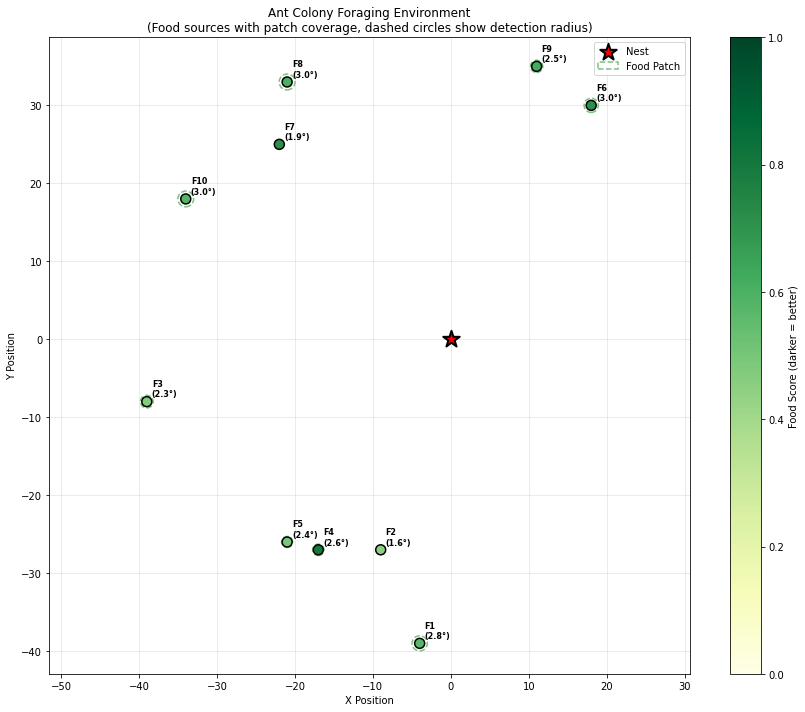

In [18]:
# Visualize nest and food locations
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 10))

# Plot nest
plt.scatter(NEST[0], NEST[1], s=300, c='red', marker='*', label='Nest', zorder=3, edgecolors='black', linewidths=2)

# Plot food sources colored by score (darker = better)
food_x = [loc[0] for loc in food_locations]
food_y = [loc[1] for loc in food_locations]

scatter = plt.scatter(food_x, food_y, s=100, c=food_scores, cmap='YlGn', 
                     vmin=0, vmax=1, edgecolors='black', linewidths=1.5, zorder=2)

# Add colorbar
cbar = plt.colorbar(scatter, label='Food Score (darker = better)')

# Draw food patch circles to visualize angular coverage
for i in range(len(food_locations)):
    # Calculate spatial radius from angular patch size
    angular_radius = food_patch_size[i] / 2
    spatial_radius = food_distances[i] * math.tan(math.radians(angular_radius))
    
    circle = plt.Circle((food_x[i], food_y[i]), spatial_radius, 
                        color='green', fill=False, linestyle='--', 
                        linewidth=1.5, alpha=0.5, label='Food Patch' if i == 0 else '')
    plt.gca().add_patch(circle)

# Add labels for each food source with patch size
for i in range(len(food_locations)):
    plt.annotate(f'F{i + 1}\n({food_patch_size[i]:.1f}°)', (food_x[i], food_y[i]), 
                xytext=(5, 5), textcoords='offset points', 
                fontsize=8, fontweight='bold')

plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Ant Colony Foraging Environment\n(Food sources with patch coverage, dashed circles show detection radius)')
plt.legend()
plt.grid(True, alpha=0.3)

# Fixed grid size (always -40 to +40)
plt.xlim(-SIZE, SIZE)
plt.ylim(-SIZE, SIZE)
plt.axis('equal')  # Make it square

plt.tight_layout()
plt.show()

## Define Food Detection Function

This function determines if an ant traveling at a given angle will encounter any food source within its perception range, accounting for angular patch sizes.

In [19]:
def within_range(angle):
    
    # get distance to each food patch at that angle
    # for wrap around angles (where angles are near 0/360) we need the min of either distance
    angle_distances = [
        min(abs(angle - i),360 - abs(angle - i))for i in food_locations_angles]
    angle_distances = [round(d, 1) for d in angle_distances]

    distances_with_patch_size = [round(dist - (food_patch_size[idx] / 2), 1)for idx, dist in enumerate(angle_distances)]
    #print(distances_with_patch_size)
    #print(distances_with_patch_size.index(min(distances_with_patch_size))+1,':',min(distances_with_patch_size))
    
    hit_radius = ANT_PERCEPTION # small angle range to simulate ant's limited perception (defined abover)
    # get the indices of all food patches within hit radius, as getting the min is not sufficient since the min may be a lot farther in distance
    # from the nest than the others, and the ant will encounter those first
    # IMPORTANT: Only consider food sources that still have quantity > 0
    # This simulates realistic ant behavior - they walk past depleted sources to discover food behind them
    within_hit_radius = [idx for idx, dist in enumerate(distances_with_patch_size) 
                        if dist <= hit_radius and food_quantity[idx] > 0]
    if not within_hit_radius:
        return False  # nothing hit on that   angle
    
    best_idx = min(within_hit_radius, key=lambda idx: food_distances[idx])
    return best_idx



## Define Pheromone Deposit Strength Function

Determines how much pheromone an ant deposits based on food source quality. Uses non-linear scaling to amplify good sources and diminish poor ones.

In [20]:
def pheromone_deposit(food_idx):
    
    """Calculate pheromone deposit based on current food quantity and fixed attributes"""
    
    norm_quant = normalize(food_quantity, min_quant, max_quant, invert=False)
    nqty = norm_quant[food_idx]
    
    # Use pre-calculated normalized values for everything else (from first cell)
    nd = norm_dist[food_idx]
    nqlty = norm_qual[food_idx]
    nea = norm_ease[food_idx]
    
    # Same weights as original
    base_deposit = nd * 0.4 + nqlty * 0.225 + nqty * 0.225 + nea * 0.15
    #print('B:', base_deposit)
    # print('B:', base_deposit)
    # Non-linear scaling based on quality
    midpoint = 0.6  # Threshold between penalty and reward
    range = .06
    if base_deposit <= (midpoint - range):
        # PENALTY: Use square root to gently diminish low scores
        # Maps [0.1, 0.6] → [~0.03, 0.6]
        # This makes bad sources even less attractive
        deposit = ((base_deposit ** 1.5) * .75) 
    elif base_deposit >= (midpoint + range):
        # REWARD: Use power function to amplify high scores
        # Maps [0.6, 1.1] → [0.6, ~2.5]
        # This makes good sources MUCH more attractive
        excess = base_deposit - midpoint
        deposit = (midpoint + (excess ** 0.4) * 1.85) 
    else:
        deposit = base_deposit  # Neutral zone, no adjustment

    return deposit

    

## Run Ant Colony Simulation

Execute the main simulation where ants use pheromone trails to find food. Scout ants explore randomly, while others follow the strongest pheromone paths. Pheromones evaporate over time.

In [21]:
# Iterations (or use the food amount as number of iterations)
ANTS = 10000
total_food = sum(food_quantity)
iter_num = 0
scout_iter = 12
evap_iter = 8
negligible_pheromone_threshold = 0.05
evaporation_rate = 0.35  

# store peheromone levels for each food source, initialized to zero
pheremone_levels = [0 for _ in range(len(food_locations))]
food_paths = [0 for _ in range(len(food_locations))]
actual_ant_paths = []
# for calculating when food was depleted
iters = []

print(f"Starting Food Supply: {total_food}\n")

for i in range(ANTS):
  iter_num += 1
  
  # if no more pheremones on the any paths end simulation
  if max(pheremone_levels) <= negligible_pheromone_threshold and sum(food_quantity) <= 0:
      print("All food depleted and no pheromones left. Ending simulation.")
      break
    
  # get best path pheromone level
  max_pher = max(pheremone_levels)
  best_path = max_pher if max_pher > negligible_pheromone_threshold else 0
  
  # display ant paths every 100 ants
  if iter_num % 200 == 0:
        print(f"Ant Iteration: {iter_num}")
        print(f"Paths: {food_paths}")
        print(f"Quantity: {food_quantity}")
        print(f"Phereomone Levels: {[round(x,2) for x in pheremone_levels]}")
        print(sum(food_quantity))
        print()

  # get random path for scout or if no pheremones yet
  if iter_num % scout_iter == 0 or best_path == 0:
                # random exploration
                angle = rd.randint(0, 360)

                hit = within_range(angle)
                if hit is not False:
                    food_paths[hit] += 1 
                    
                    # simulate food being taken if available and add pheremone to path since food was found
                    if food_quantity[hit] > 0:
                       food_quantity[hit] -= 1 
                       pheremone_levels[hit] += pheromone_deposit(hit)
                    actual_ant_paths.append((iter_num, angle, 'scout'))
                else: 
                  actual_ant_paths.append((iter_num, angle, 'scout'))
  else:           
                # follow best pheromone path
                best_indices = [idx for idx, p in enumerate(pheremone_levels) if p == best_path]
                best_index = rd.choice(best_indices)
                food_paths[best_index] += 1
                if food_quantity[best_index] > 0:
                  food_quantity[best_index] -= 1
                  pheremone_levels[best_index] += pheromone_deposit(best_index)
                  
                actual_ant_paths.append((iter_num, food_locations_angles[best_index], 'follower'))
  
  # evaporation step
  if iter_num % evap_iter == 0:
    pheremone_levels = [max(p * (1 - evaporation_rate), 0) for p in pheremone_levels]
  

# Calculate exact iteration when food was depleted
  if sum(food_quantity) == 0:
    iters.append(iter_num)
    


print(f"\n✅ Simulation complete! {iter_num} ants processed")
print(f"Food was depleted after {min(iters) if iters else 'not depleted during simulation'} iterations")




Starting Food Supply: 6586

Ant Iteration: 200
Paths: [1, 182, 0, 1, 1, 1, 0, 1, 0, 0]
Quantity: [810, 89, 552, 691, 591, 890, 380, 891, 605, 900]
Phereomone Levels: [0.0, 4.14, 0.0, 0.0, 0.05, 0.0, 0.0, 0.39, 0.0, 0.0]
6399

Ant Iteration: 400
Paths: [1, 344, 0, 2, 1, 1, 19, 1, 0, 0]
Quantity: [810, 0, 552, 690, 591, 890, 361, 891, 605, 900]
Phereomone Levels: [0.0, 0.02, 0.0, 0.0, 0.0, 0.0, 18.12, 0.0, 0.0, 0.0]
6290

Ant Iteration: 600
Paths: [1, 344, 0, 2, 1, 3, 203, 1, 1, 2]
Quantity: [810, 0, 552, 690, 591, 888, 177, 891, 604, 898]
Phereomone Levels: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 26.62, 0.0, 0.11, 0.0]
6101

Ant Iteration: 800
Paths: [1, 344, 0, 3, 1, 4, 386, 1, 1, 2]
Quantity: [810, 0, 552, 689, 591, 887, 0, 891, 604, 898]
Phereomone Levels: [0.0, 0.0, 0.0, 0.05, 0.0, 0.25, 9.37, 0.0, 0.0, 0.0]
5922

Ant Iteration: 1000
Paths: [1, 344, 1, 3, 1, 129, 445, 1, 2, 2]
Quantity: [810, 0, 551, 689, 591, 762, 0, 891, 603, 898]
Phereomone Levels: [0.0, 0.0, 0.07, 0.0, 0.0, 25.9, 0.0, 0.

## Inspect a Slice of Actual Ant Paths

Choose a start and end index to inspect a portion of `actual_ant_paths` from the main ant colony simulation.

Each entry in `actual_ant_paths` is a tuple in this format:
- `(iteration, angle, role)`
- `iteration`: which ant iteration produced the path
- `angle`: the travel angle in degrees
- `role`: whether the ant was a `scout` or `follower`

Update the two numbers in the next cell and re-run it to inspect any slice of the recorded paths.

In [22]:
from IPython.display import Markdown, display

# Change these two numbers to inspect any portion of actual_ant_paths
start_index = 0
end_index = 25

path_count = len(actual_ant_paths)

if path_count == 0:
    display(Markdown(
        "**No ant paths were recorded yet.**  \nRun the main simulation cell first, then re-run this inspector cell."
    ))
else:
    start_index = max(0, int(start_index))
    end_index = min(path_count, int(end_index))

    if start_index >= end_index:
        display(Markdown(
            f"**Invalid slice.** `start_index` ({start_index}) must be smaller than `end_index` ({end_index})."
        ))
    else:
        selected_paths = actual_ant_paths[start_index:end_index]

        display(Markdown(
            f"### Actual Ant Path Slice\n"
            f"Showing entries **{start_index}** to **{end_index - 1}** out of **{path_count}** total recorded paths.\n\n"
            f"Each row shows the **list index**, **simulation iteration**, **travel angle**, and whether the ant was a **scout** or **follower**."
        ))

        table_lines = [
            "| List Index | Iteration | Angle (°) | Role |",
            "|---:|---:|---:|:---|"
        ]

        for offset, (iteration, angle, role) in enumerate(selected_paths, start=start_index):
            table_lines.append(f"| {offset} | {iteration} | {angle:.2f} | {role} |")

        display(Markdown("\n".join(table_lines)))

### Actual Ant Path Slice
Showing entries **0** to **24** out of **7824** total recorded paths.

Each row shows the **list index**, **simulation iteration**, **travel angle**, and whether the ant was a **scout** or **follower**.

| List Index | Iteration | Angle (°) | Role |
|---:|---:|---:|:---|
| 0 | 1 | 108.00 | scout |
| 1 | 2 | 15.00 | scout |
| 2 | 3 | 249.00 | scout |
| 3 | 4 | 251.57 | follower |
| 4 | 5 | 251.57 | follower |
| 5 | 6 | 251.57 | follower |
| 6 | 7 | 251.57 | follower |
| 7 | 8 | 251.57 | follower |
| 8 | 9 | 251.57 | follower |
| 9 | 10 | 251.57 | follower |
| 10 | 11 | 251.57 | follower |
| 11 | 12 | 265.00 | scout |
| 12 | 13 | 251.57 | follower |
| 13 | 14 | 251.57 | follower |
| 14 | 15 | 251.57 | follower |
| 15 | 16 | 251.57 | follower |
| 16 | 17 | 251.57 | follower |
| 17 | 18 | 251.57 | follower |
| 18 | 19 | 251.57 | follower |
| 19 | 20 | 251.57 | follower |
| 20 | 21 | 251.57 | follower |
| 21 | 22 | 251.57 | follower |
| 22 | 23 | 251.57 | follower |
| 23 | 24 | 239.00 | scout |
| 24 | 25 | 251.57 | follower |

## Save Ant Colony Results

Store the ant colony results (visit counts and iterations) for later comparison with random exploration.

In [23]:
# 💾 SAVE ANT COLONY RESULTS (with pheromones)
# Store these results before running the random simulation!
ant_colony_paths = food_paths.copy()
ant_colony_iterations = iter_num  # Save iteration count

print("✅ Ant Colony results saved!")
print(f"Ant Colony Visits: {ant_colony_paths}")
print(f"Total visits to Food Locations: {sum(ant_colony_paths)}")
print(f"Iterations to deplete food: {ant_colony_iterations}")


✅ Ant Colony results saved!
Ant Colony Visits: [879, 344, 619, 745, 661, 909, 445, 928, 680, 967]
Total visits to Food Locations: 7177
Iterations to deplete food: 7825


## Run Random Exploration Simulation

Execute a comparison simulation where ants explore completely randomly without pheromone communication. Captures a snapshot at the same iteration count as the ant colony for fair comparison.

In [24]:
def within_range(angle):
    
    # get distance to each food patch at that angle
    # for wrap around angles (where angles are near 0/360) we need the min of either distance
    angle_distances = [
        min(abs(angle - i),360 - abs(angle - i))for i in food_locations_angles]
    angle_distances = [round(d, 1) for d in angle_distances]

    distances_with_patch_size = [round(dist - (food_patch_size[idx] / 2), 1)for idx, dist in enumerate(angle_distances)]
    #print(distances_with_patch_size)
    #print(distances_with_patch_size.index(min(distances_with_patch_size))+1,':',min(distances_with_patch_size))
    
    hit_radius = 3 # small angle range to simulate ant's limited perception
    # get the indices of all food patches within hit radius, as getting the min is not sufficient since the min may be a lot farther in distance
    # from the nest than the others, and the ant will encounter those first
    # IMPORTANT: Only consider food sources that still have quantity > 0
    # This simulates realistic ant behavior - they walk past depleted sources to discover food behind them
    within_hit_radius = [idx for idx, dist in enumerate(distances_with_patch_size) 
                        if dist <= hit_radius and food_quantity_copy[idx] > 0]
    if not within_hit_radius:
        return False  # nothing hit on that   angle
    
    best_idx = min(within_hit_radius, key=lambda idx: food_distances[idx])
    return best_idx

# Random exploration - runs until all food is depleted
total_food = sum(food_quantity_copy)
iter_num = 0


# store peheromone levels for each food source, initialized to zero
food_paths = [0 for _ in range(len(food_locations))]
actual_ant_paths = []

# 🎯 NEW: Track state at ant colony completion point for fair comparison
random_paths_at_ant_completion = None
food_collected_at_ant_completion = None

print(f"Starting Food Supply: {total_food}\n")
print(f"🎯 Will capture snapshot at iteration {ant_colony_iterations} (when ant colony finished)\n")

# Continue until all food is depleted
while sum(food_quantity_copy) > 0:
  iter_num += 1
  
  # 🎯 NEW: Capture snapshot when we reach ant colony's completion iteration
  if iter_num == ant_colony_iterations:
      random_paths_at_ant_completion = food_paths.copy()
      food_collected_at_ant_completion = [original_food_quantity[i] - food_quantity_copy[i] 
                                          for i in range(len(original_food_quantity))]
      print(f"📸 SNAPSHOT at iteration {ant_colony_iterations}:")
      print(f"   Random has collected: {sum(food_collected_at_ant_completion)}/{sum(original_food_quantity)} food items")
      print(f"   Progress: {sum(food_collected_at_ant_completion)/sum(original_food_quantity)*100:.1f}%")
      print()
  
  # display ant paths every 200 ants
  if iter_num % 200 == 0:
        print(f"Ant Iteration: {iter_num}")
        print(f"Paths: {food_paths}")
        print(f"Quantity: {food_quantity_copy}")
        print(sum(food_quantity_copy))
        print()

  # random exploration
  angle = rd.randint(0, 360)
  hit = within_range(angle)
  if hit is not False:
        food_paths[hit] += 1 
                        
    # simulate food being taken if available
        if food_quantity_copy[hit] > 0:
            food_quantity_copy[hit] -= 1 
  else: 
        actual_ant_paths.append((iter_num, angle))
        
  

print(f"\n✅ Simulation complete! {iter_num} ants processed")
print(f"All food depleted after {iter_num} iterations")
print(f"{sum(food_quantity_copy)} units of food remaining.")


Starting Food Supply: 6586

🎯 Will capture snapshot at iteration 7825 (when ant colony finished)

Ant Iteration: 200
Paths: [3, 4, 8, 2, 5, 3, 6, 5, 6, 6]
Quantity: [808, 267, 544, 690, 587, 888, 374, 887, 599, 894]
6538

Ant Iteration: 400
Paths: [8, 7, 13, 4, 8, 8, 7, 12, 10, 9]
Quantity: [803, 264, 539, 688, 584, 883, 373, 880, 595, 891]
6500

Ant Iteration: 600
Paths: [13, 12, 14, 10, 9, 15, 13, 17, 16, 13]
Quantity: [798, 259, 538, 682, 583, 876, 367, 875, 589, 887]
6454

Ant Iteration: 800
Paths: [16, 21, 17, 14, 14, 18, 20, 22, 19, 19]
Quantity: [795, 250, 535, 678, 578, 873, 360, 870, 586, 881]
6406

Ant Iteration: 1000
Paths: [22, 21, 20, 18, 17, 23, 22, 29, 22, 25]
Quantity: [789, 250, 532, 674, 575, 868, 358, 863, 583, 875]
6367

Ant Iteration: 1200
Paths: [26, 25, 25, 25, 19, 26, 29, 33, 27, 31]
Quantity: [785, 246, 527, 667, 573, 865, 351, 859, 578, 869]
6320

Ant Iteration: 1400
Paths: [34, 34, 27, 32, 22, 28, 33, 38, 29, 36]
Quantity: [777, 237, 525, 660, 570, 863, 347, 

## Save Random Exploration Results

Store the random exploration results at both the comparison point (same iterations as ant colony) and full completion (all food depleted).

In [25]:
# 💾 SAVE RANDOM EXPLORATION RESULTS
# Store these results for comparison

# Full completion results (when ALL food depleted)
random_paths = food_paths.copy()
random_iterations = iter_num  # Save iteration count

# 🎯 NEW: Fair comparison results (at ant colony completion point)
random_paths_at_comparison = random_paths_at_ant_completion.copy()
food_collected_at_comparison = food_collected_at_ant_completion.copy()

print("✅ Random exploration results saved!")
print(f"\n📊 FULL COMPLETION (all food depleted):")
print(f"   Random Visits: {random_paths}")
print(f"   Total visits: {sum(random_paths)}")
print(f"   Iterations to deplete food: {random_iterations}")

print(f"\n🎯 FAIR COMPARISON (at iteration {ant_colony_iterations}):")
print(f"   Random Visits: {random_paths_at_comparison}")
print(f"   Total visits: {sum(random_paths_at_comparison)}")
print(f"   Food collected: {sum(food_collected_at_comparison)}/{sum(original_food_quantity)} ({sum(food_collected_at_comparison)/sum(original_food_quantity)*100:.1f}%)")


✅ Random exploration results saved!

📊 FULL COMPLETION (all food depleted):
   Random Visits: [811, 271, 552, 692, 592, 891, 380, 892, 605, 900]
   Total visits: 6586
   Iterations to deplete food: 36173

🎯 FAIR COMPARISON (at iteration 7825):
   Random Visits: [196, 175, 179, 192, 144, 192, 171, 223, 168, 204]
   Total visits: 1844
   Food collected: 1844/6586 (28.0%)


## Compare Efficiency: Iterations to Complete

Visualize how many iterations each method (ideal, ant colony, random) took to deplete all food. Shows efficiency gains from pheromone communication.


⏱️  EFFICIENCY COMPARISON: Iterations to Deplete All Food

Total Food Items: 6586

1. Ideal (Perfect Knowledge):  6,586 iterations
   → Each food item collected exactly once (theoretical minimum)

2. Ant Colony (Pheromones):    7,825 iterations
   → 118.8% of ideal
   → 1,239 extra iterations

3. Random Exploration:         36,173 iterations
   → 549.2% of ideal
   → 29,587 extra iterations

💡 EFFICIENCY GAIN:
   Ant Colony is 78.4% faster than Random
   Ant Colony saved 28,348 iterations!


<ipython-input-26-d71e7f9b3744>:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


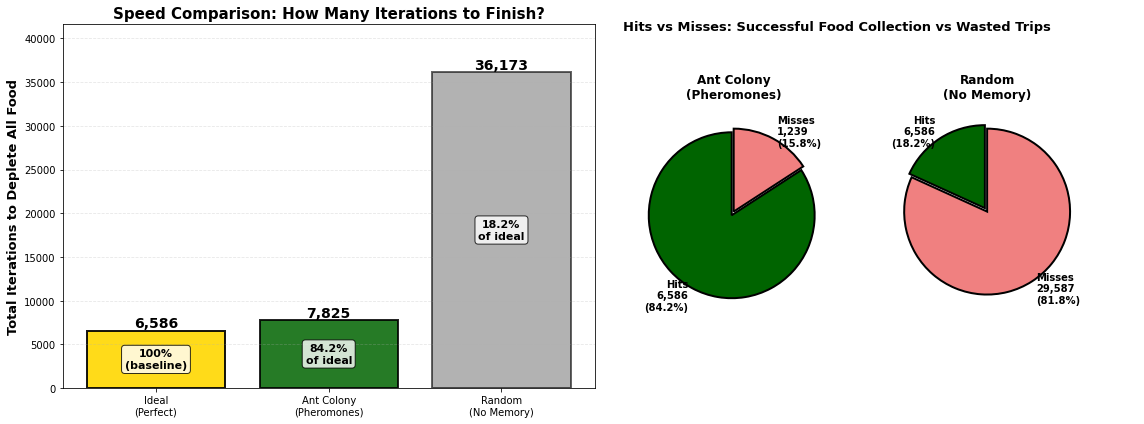


📊 DETAILED BREAKDOWN:
   Ideal:       6,586 iterations (0% waste)
   Ant Colony:  7,825 iterations (15.8% waste)
   Random:      36,173 iterations (81.8% waste)


In [26]:
# 📊 VISUALIZATION: Iterations to Complete Food Depletion
import matplotlib.pyplot as plt
import numpy as np
import warnings

# Suppress matplotlib font warnings for missing emoji glyphs
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

# Calculate ideal iterations (perfect allocation - each piece of food visited exactly once)
total_food_items = sum(original_food_quantity)
ideal_iterations = total_food_items

# Get actual iterations from simulations
ant_colony_iters = ant_colony_iterations
random_iters = random_iterations

print("\n" + "="*80)
print("⏱️  EFFICIENCY COMPARISON: Iterations to Deplete All Food")
print("="*80)
print(f"\nTotal Food Items: {total_food_items}")
print(f"\n1. Ideal (Perfect Knowledge):  {ideal_iterations:,} iterations")
print(f"   → Each food item collected exactly once (theoretical minimum)")
print(f"\n2. Ant Colony (Pheromones):    {ant_colony_iters:,} iterations")
print(f"   → {((ant_colony_iters / ideal_iterations) * 100):.1f}% of ideal")
print(f"   → {ant_colony_iters - ideal_iterations:,} extra iterations")
print(f"\n3. Random Exploration:         {random_iters:,} iterations")
print(f"   → {((random_iters / ideal_iterations) * 100):.1f}% of ideal")
print(f"   → {random_iters - ideal_iterations:,} extra iterations")
print(f"\n💡 EFFICIENCY GAIN:")
print(f"   Ant Colony is {((random_iters - ant_colony_iters) / random_iters * 100):.1f}% faster than Random")
print(f"   Ant Colony saved {random_iters - ant_colony_iters:,} iterations!")
print("="*80)

# Calculate hits vs misses
ant_colony_hits = total_food_items
ant_colony_misses = ant_colony_iters - total_food_items
random_hits = total_food_items
random_misses = random_iters - total_food_items

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Bar Chart - Iterations Comparison ---
methods = ['Ideal\n(Perfect)', 'Ant Colony\n(Pheromones)', 'Random\n(No Memory)']
iterations = [ideal_iterations, ant_colony_iters, random_iters]
colors = ['gold', 'darkgreen', 'gray']
alphas = [0.9, 0.85, 0.6]

# Create bars without alpha parameter
bars = ax1.bar(methods, iterations, color=colors, edgecolor='black', linewidth=2)

# Set alpha individually for each bar
for bar, alpha in zip(bars, alphas):
    bar.set_alpha(alpha)

# Add value labels on bars
for bar, iter_val in zip(bars, iterations):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{iter_val:,}',
             ha='center', va='bottom', fontsize=14, fontweight='bold')

ax1.set_ylabel('Total Iterations to Deplete All Food', fontsize=13, fontweight='bold')
ax1.set_title('Speed Comparison: How Many Iterations to Finish?', fontsize=15, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_ylim(0, max(iterations) * 1.15)

# Add efficiency percentages
efficiency_texts = [
    '100%\n(baseline)',
    f'{(ideal_iterations/ant_colony_iters*100):.1f}%\nof ideal',
    f'{(ideal_iterations/random_iters*100):.1f}%\nof ideal'
]
for i, (bar, text) in enumerate(zip(bars, efficiency_texts)):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() * 0.5,
             text,
             ha='center', va='center', fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='black'))


# --- Plot 2: Pie Charts - Hits vs Misses ---
# Create two side-by-side pie charts
ax2.axis('off')  # Turn off the main axis

# Create sub-axes for the two pie charts
ax2_left = fig.add_axes([0.55, 0.15, 0.18, 0.7])  # [left, bottom, width, height]
ax2_right = fig.add_axes([0.77, 0.15, 0.18, 0.7])

# Ant Colony pie chart
ant_sizes = [ant_colony_hits, ant_colony_misses]
ant_labels = [f'Hits\n{ant_colony_hits:,}\n({ant_colony_hits/ant_colony_iters*100:.1f}%)', 
              f'Misses\n{ant_colony_misses:,}\n({ant_colony_misses/ant_colony_iters*100:.1f}%)']
ant_colors = ['darkgreen', 'lightcoral']
ant_explode = (0.05, 0)

wedges1, texts1, autotexts1 = ax2_left.pie(ant_sizes, labels=ant_labels, colors=ant_colors, 
                                             explode=ant_explode, autopct='', startangle=90,
                                             textprops={'fontsize': 10, 'fontweight': 'bold'},
                                             wedgeprops={'edgecolor': 'black', 'linewidth': 2})
ax2_left.set_title('Ant Colony\n(Pheromones)', fontsize=12, fontweight='bold', pad=10)

# Random pie chart
random_sizes = [random_hits, random_misses]
random_labels = [f'Hits\n{random_hits:,}\n({random_hits/random_iters*100:.1f}%)', 
                 f'Misses\n{random_misses:,}\n({random_misses/random_iters*100:.1f}%)']
random_colors = ['darkgreen', 'lightcoral']
random_explode = (0.05, 0)

wedges2, texts2, autotexts2 = ax2_right.pie(random_sizes, labels=random_labels, colors=random_colors, 
                                              explode=random_explode, autopct='', startangle=90,
                                              textprops={'fontsize': 10, 'fontweight': 'bold'},
                                              wedgeprops={'edgecolor': 'black', 'linewidth': 2})
ax2_right.set_title('Random\n(No Memory)', fontsize=12, fontweight='bold', pad=10)

# Add main title for the pie chart section
fig.text(0.73, 0.92, 'Hits vs Misses: Successful Food Collection vs Wasted Trips', 
         ha='center', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Additional stats
print(f"\n📊 DETAILED BREAKDOWN:")
print(f"   Ideal:       {ideal_iterations:,} iterations (0% waste)")
print(f"   Ant Colony:  {ant_colony_iters:,} iterations ({(ant_colony_misses/ant_colony_iters*100):.1f}% waste)")
print(f"   Random:      {random_iters:,} iterations ({(random_misses/random_iters*100):.1f}% waste)")


## Analyze Proportional Visit Allocation

Examine whether visits to food sources are proportional to their availability and quality. Compares ant colony's smart allocation vs random's uniform distribution.


📊 PROPORTIONAL VISIT ALLOCATION: Are visits distributed according to food availability?

Source   Food       Ideal %      Ant Colony                Random                    Score   
ID       Qty        (Target)     Visits (% of Total)       Visits (% of Total)       (Quality)
------------------------------------------------------------------------------------------------------------------------
F1       811         12.31%      879     (12.25%) ✓    196     (10.63%) ✓    0.57  
F2       271          4.11%      344     ( 4.79%) ✓    175     ( 9.49%) ↑    0.45  
F3       552          8.38%      619     ( 8.62%) ✓    179     ( 9.71%) ✓    0.48  
F4       692         10.51%      745     (10.38%) ✓    192     (10.41%) ✓    0.80  
F5       592          8.99%      661     ( 9.21%) ✓    144     ( 7.81%) ✓    0.50  
F6       891         13.53%      909     (12.67%) ✓    192     (10.41%) ↓    0.71  
F7       380          5.77%      445     ( 6.20%) ✓    171     ( 9.27%) ↑    0.71  
F8       892

c:\Python\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Python\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


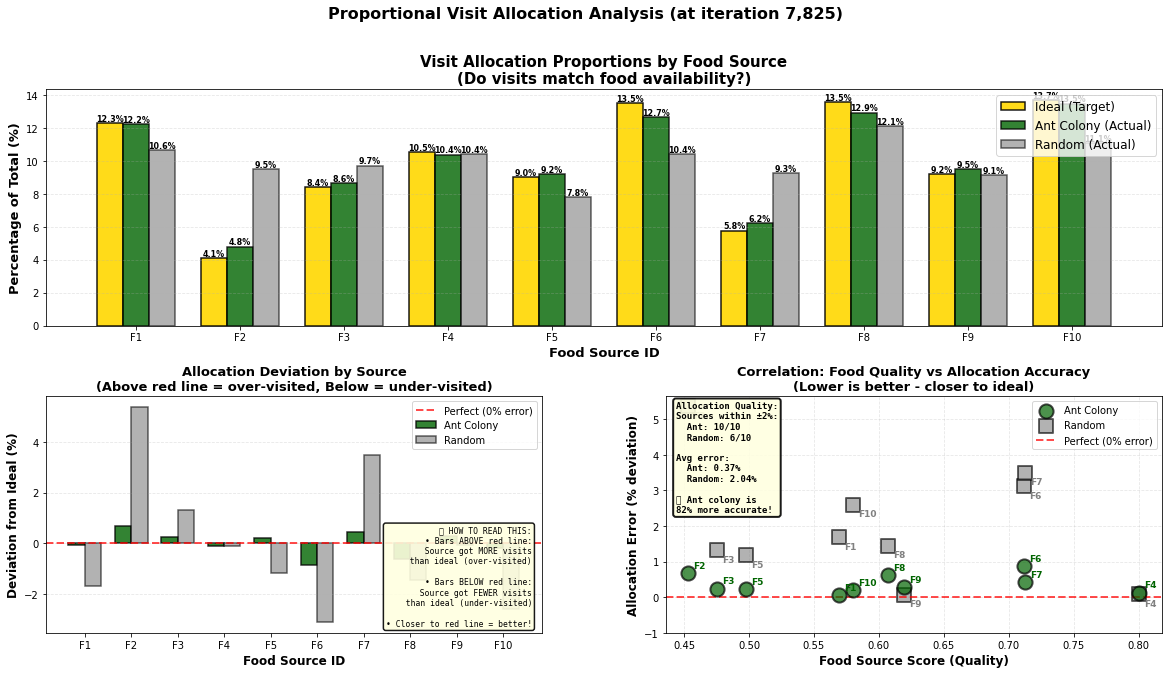


🎯 KEY INSIGHTS:

1. BEST ALLOCATED SOURCES (Ant Colony):
   F1: 0.07% error (ideal: 12.3%, actual: 12.2%)
   F4: 0.13% error (ideal: 10.5%, actual: 10.4%)
   F10: 0.19% error (ideal: 13.7%, actual: 13.5%)

2. WORST ALLOCATED SOURCES (Ant Colony):
   F6: 0.86% error (ideal: 13.5%, actual: 12.7%)
   F2: 0.68% error (ideal: 4.1%, actual: 4.8%)
   F8: 0.61% error (ideal: 13.5%, actual: 12.9%)

3. RANDOM ALLOCATION PATTERN:
   Average visit proportion: 10.00% (should vary by source)
   Standard deviation: 1.13%
   → Random tends toward UNIFORM distribution (bad!)

4. ANT COLONY ALLOCATION PATTERN:
   Correlation with food scores: 0.281
   Correlation with food quantities: 0.997
   → Pheromones create SMART allocation (good!)


In [27]:
# 📊 VISUALIZATION: Proportional Visit Allocation Analysis
# Are visits distributed proportionally to food quantities?
import matplotlib.pyplot as plt
import numpy as np

# Calculate ideal proportions (what % of total food each source represents)
total_food = sum(original_food_quantity)
ideal_proportions = [(qty / total_food * 100) for qty in original_food_quantity]

# Calculate actual visit proportions for ant colony
total_ant_visits = sum(ant_colony_paths)
ant_visit_proportions = [(visits / total_ant_visits * 100) if total_ant_visits > 0 else 0 
                          for visits in ant_colony_paths]

# Calculate actual visit proportions for random (at comparison point)
total_random_visits = sum(random_paths_at_comparison)
random_visit_proportions = [(visits / total_random_visits * 100) if total_random_visits > 0 else 0 
                             for visits in random_paths_at_comparison]

# Print detailed comparison table
print("\n" + "="*120)
print("📊 PROPORTIONAL VISIT ALLOCATION: Are visits distributed according to food availability?")
print("="*120)
print(f"\n{'Source':<8} {'Food':<10} {'Ideal %':<12} {'Ant Colony':<25} {'Random':<25} {'Score':<8}")
print(f"{'ID':<8} {'Qty':<10} {'(Target)':<12} {'Visits (% of Total)':<25} {'Visits (% of Total)':<25} {'(Quality)':<8}")
print("-"*120)

for i in range(len(original_food_quantity)):
    # Calculate how close each method got to ideal proportion
    ant_deviation = ant_visit_proportions[i] - ideal_proportions[i]
    random_deviation = random_visit_proportions[i] - ideal_proportions[i]
    
    ant_marker = "✓" if abs(ant_deviation) < 2 else ("↑" if ant_deviation > 0 else "↓")
    random_marker = "✓" if abs(random_deviation) < 2 else ("↑" if random_deviation > 0 else "↓")
    
    print(f"F{i+1:<7} {original_food_quantity[i]:<10} {ideal_proportions[i]:>6.2f}%      "
          f"{ant_colony_paths[i]:<7} ({ant_visit_proportions[i]:>5.2f}%) {ant_marker}    "
          f"{random_paths_at_comparison[i]:<7} ({random_visit_proportions[i]:>5.2f}%) {random_marker}    "
          f"{food_scores[i]:<6.2f}")

print("-"*120)
print(f"{'TOTAL':<8} {total_food:<10} 100.00%      "
      f"{total_ant_visits:<7} (100.00%)       "
      f"{total_random_visits:<7} (100.00%)")
print("="*120)

# Calculate allocation accuracy metrics
# EXPLANATION: This is simply MEAN ABSOLUTE DEVIATION (not squared!)
# For each source: |actual% - ideal%|, then average them
# Example: If 3 sources are off by 5%, 3%, 2% → average error = (5+3+2)/3 = 3.33%
ant_allocation_error = np.mean([abs(ant_visit_proportions[i] - ideal_proportions[i]) 
                                 for i in range(len(original_food_quantity))])
random_allocation_error = np.mean([abs(random_visit_proportions[i] - ideal_proportions[i]) 
                                    for i in range(len(original_food_quantity))])

print(f"\n💡 ALLOCATION ACCURACY (Mean Absolute Deviation):")
print(f"   📐 Formula: Average of |actual% - ideal%| across all sources")
print(f"   Ant Colony: {ant_allocation_error:.2f}% average deviation from ideal")
print(f"   Random:     {random_allocation_error:.2f}% average deviation from ideal")
print(f"   Improvement: {((random_allocation_error - ant_allocation_error) / random_allocation_error * 100):.1f}% better allocation by ant colony!")

# Create comprehensive visualization
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)

# --- Plot 1: Stacked Bar Chart - Proportional Distribution ---
ax1 = fig.add_subplot(gs[0, :])
x = np.arange(len(original_food_quantity))
width = 0.25

bars1 = ax1.bar(x - width, ideal_proportions, width, label='Ideal (Target)', 
                color='gold', alpha=0.9, edgecolor='black', linewidth=1.5)
bars2 = ax1.bar(x, ant_visit_proportions, width, label='Ant Colony (Actual)', 
                color='darkgreen', alpha=0.8, edgecolor='black', linewidth=1.5)
bars3 = ax1.bar(x + width, random_visit_proportions, width, label='Random (Actual)', 
                color='gray', alpha=0.6, edgecolor='black', linewidth=1.5)

ax1.set_xlabel('Food Source ID', fontsize=13, fontweight='bold')
ax1.set_ylabel('Percentage of Total (%)', fontsize=13, fontweight='bold')
ax1.set_title('Visit Allocation Proportions by Food Source\n(Do visits match food availability?)', 
              fontsize=15, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([f'F{i+1}' for i in range(len(original_food_quantity))])
ax1.legend(loc='upper right', fontsize=12)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars (only show if > 3% to avoid clutter)
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 3:
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

# --- Plot 2: Deviation from Ideal (Left bottom) ---
# SIMPLIFIED: Use consistent colors, not conditional
ax2 = fig.add_subplot(gs[1, 0])

ant_deviations = [ant_visit_proportions[i] - ideal_proportions[i] 
                  for i in range(len(original_food_quantity))]
random_deviations = [random_visit_proportions[i] - ideal_proportions[i] 
                     for i in range(len(original_food_quantity))]

x_pos = np.arange(len(original_food_quantity))
width = 0.35

# Use CONSISTENT colors: green for ant colony, gray for random
# Bars above zero = over-visited (too many visits)
# Bars below zero = under-visited (too few visits)
bars_dev1 = ax2.bar(x_pos - width/2, ant_deviations, width, label='Ant Colony', 
                     color='darkgreen', alpha=0.8, edgecolor='black', linewidth=1.5)
bars_dev2 = ax2.bar(x_pos + width/2, random_deviations, width, label='Random', 
                     color='gray', alpha=0.6, edgecolor='black', linewidth=1.5)

ax2.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Perfect (0% error)')
ax2.set_xlabel('Food Source ID', fontsize=12, fontweight='bold')
ax2.set_ylabel('Deviation from Ideal (%)', fontsize=12, fontweight='bold')
ax2.set_title('Allocation Deviation by Source\n(Above red line = over-visited, Below = under-visited)', 
              fontsize=13, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'F{i+1}' for i in range(len(original_food_quantity))])
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Add annotation box explaining the plot
explanation = "📊 HOW TO READ THIS:\n" \
              "• Bars ABOVE red line:\n" \
              "  Source got MORE visits\n" \
              "  than ideal (over-visited)\n\n" \
              "• Bars BELOW red line:\n" \
              "  Source got FEWER visits\n" \
              "  than ideal (under-visited)\n\n" \
              "• Closer to red line = better!"
ax2.text(0.98, 0.02, explanation,
         transform=ax2.transAxes, fontsize=8,
         verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9, edgecolor='black', linewidth=1.5),
         family='monospace')

# --- Plot 3: Allocation Quality vs Food Score (Right bottom) ---
ax3 = fig.add_subplot(gs[1, 1])

# Calculate allocation accuracy per source (lower is better)
ant_accuracy = [abs(ant_visit_proportions[i] - ideal_proportions[i]) 
                for i in range(len(original_food_quantity))]
random_accuracy = [abs(random_visit_proportions[i] - ideal_proportions[i]) 
                   for i in range(len(original_food_quantity))]

ax3.scatter(food_scores, ant_accuracy, s=200, c='darkgreen', alpha=0.7, 
           edgecolors='black', linewidths=2, label='Ant Colony', marker='o', zorder=3)
ax3.scatter(food_scores, random_accuracy, s=200, c='gray', alpha=0.6, 
           edgecolors='black', linewidths=2, label='Random', marker='s', zorder=2)

# Add labels
for i in range(len(food_scores)):
    ax3.annotate(f'F{i+1}', (food_scores[i], ant_accuracy[i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold',
                color='darkgreen')
    ax3.annotate(f'F{i+1}', (food_scores[i], random_accuracy[i]), 
                xytext=(5, -12), textcoords='offset points', fontsize=9, fontweight='bold',
                color='gray')

ax3.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Perfect (0% error)')
ax3.set_xlabel('Food Source Score (Quality)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Allocation Error (% deviation)', fontsize=12, fontweight='bold')
ax3.set_title('Correlation: Food Quality vs Allocation Accuracy\n(Lower is better - closer to ideal)', 
             fontsize=13, fontweight='bold')
ax3.legend(loc='upper right', fontsize=10)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_ylim(bottom=-1)

# Add insight text box
well_allocated_ant = sum(1 for acc in ant_accuracy if acc < 2)
well_allocated_random = sum(1 for acc in random_accuracy if acc < 2)

textstr = f'Allocation Quality:\n' \
          f'Sources within ±2%:\n' \
          f'  Ant: {well_allocated_ant}/{len(original_food_quantity)}\n' \
          f'  Random: {well_allocated_random}/{len(original_food_quantity)}\n\n' \
          f'Avg error:\n' \
          f'  Ant: {ant_allocation_error:.2f}%\n' \
          f'  Random: {random_allocation_error:.2f}%\n\n' \
          f'🎯 Ant colony is\n{((random_allocation_error - ant_allocation_error) / random_allocation_error * 100):.0f}% more accurate!'
ax3.text(0.02, 0.98, textstr,
         transform=ax3.transAxes, fontsize=9,
         verticalalignment='top', horizontalalignment='left',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9, edgecolor='black', linewidth=2),
         family='monospace', fontweight='bold')

plt.suptitle(f'Proportional Visit Allocation Analysis (at iteration {ant_colony_iterations:,})', 
             fontsize=16, fontweight='bold', y=0.995)
plt.show()

# Print detailed insights
print(f"\n🎯 KEY INSIGHTS:")
print(f"\n1. BEST ALLOCATED SOURCES (Ant Colony):")
best_ant = sorted(enumerate(ant_accuracy), key=lambda x: x[1])[:3]
for idx, error in best_ant:
    print(f"   F{idx+1}: {error:.2f}% error (ideal: {ideal_proportions[idx]:.1f}%, actual: {ant_visit_proportions[idx]:.1f}%)")

print(f"\n2. WORST ALLOCATED SOURCES (Ant Colony):")
worst_ant = sorted(enumerate(ant_accuracy), key=lambda x: x[1], reverse=True)[:3]
for idx, error in worst_ant:
    print(f"   F{idx+1}: {error:.2f}% error (ideal: {ideal_proportions[idx]:.1f}%, actual: {ant_visit_proportions[idx]:.1f}%)")

print(f"\n3. RANDOM ALLOCATION PATTERN:")
print(f"   Average visit proportion: {np.mean(random_visit_proportions):.2f}% (should vary by source)")
print(f"   Standard deviation: {np.std(random_visit_proportions):.2f}%")
print(f"   → Random tends toward UNIFORM distribution (bad!)")

print(f"\n4. ANT COLONY ALLOCATION PATTERN:")
print(f"   Correlation with food scores: {np.corrcoef(food_scores, ant_visit_proportions)[0,1]:.3f}")
print(f"   Correlation with food quantities: {np.corrcoef(original_food_quantity, ant_visit_proportions)[0,1]:.3f}")
print(f"   → Pheromones create SMART allocation (good!)")
